In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder
# 원핫 인코더
from sklearn.preprocessing import OneHotEncoder

# 학습 모델 성능 관련 #######################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습 곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 모델 성능 평가 ########################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 #########################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습 모델 ########################
# 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier 
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier

# 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge
from catboost import CatBoostRegressor

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 차원 축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# 연관 규칙 학습
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth
# 최적의 군집 개수를 계산하기 위해..
from kneed import KneeLocator
# 실루엣 계수
from sklearn.metrics import silhouette_score

# 파이프라인
from sklearn.pipeline import Pipeline

# KDE를 그리기 위한 통계값을 구할 수 있는 함수
from scipy.stats import gaussian_kde

# 피어슨 상관 계수 (연속형 수치형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pearsonr
# 카이제곱 검증 (범주형 데이터 vs 범주형 데이터, 순위X)
from scipy.stats import chi2_contingency
# 스피어만 상관계수 (범주형 데이터 vs 범주형 데이터, 순위O)
from scipy.stats import spearmanr
# 포인트 이분 상관계수 (범주형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pointbiserialr

# 오버 샘플링
from imblearn.over_sampling import SMOTE

# 객체를 파일에 저장
import pickle

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 데이터를 불러온다.

In [2]:
df = pd.read_csv('data/Mall_Customers3.csv')
df

,Age,Income,Score,Is_Young,Spending_Ratio,Age_Income_product,Gender_Numeric
0,19,15,39,1,2.600000,285,1
1,21,15,81,1,5.400000,315,1
2,20,16,6,1,0.375000,320,0
3,23,16,77,1,4.812500,368,0
4,31,17,40,1,2.352941,527,0
...,...,...,...,...,...,...,...
195,35,120,79,1,0.658333,4200,0
196,45,126,28,0,0.222222,5670,0
197,32,126,74,1,0.587302,4032,1
198,32,137,18,1,0.131387,4384,1


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled

array([[-1.42456879, -1.73899919, -0.43480148, ...,  1.57724431,
        -1.68953219,  1.12815215],
       [-1.28103541, -1.73899919,  1.19570407, ...,  4.46095966,
        -1.66496587,  1.12815215],
       [-1.3528021 , -1.70082976, -1.71591298, ..., -0.71427949,
        -1.66087149, -0.88640526],
       ...,
       [-0.49160182,  2.49780745,  0.92395314, ..., -0.49563044,
         1.37880101,  1.12815215],
       [-0.49160182,  2.91767117, -1.25005425, ..., -0.96517626,
         1.66704582,  1.12815215],
       [-0.6351352 ,  2.91767117,  1.27334719, ..., -0.47653836,
         1.44267344,  1.12815215]], shape=(200, 7))

In [5]:
# inertia 값을 담을 리스트
inertia = []

# 군집의 개수(k)를 1부터 10까지 변화시키면서 intertia 값을 측정한다.
for k in range(1, 11) :
    # kmeans 생성
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    # inertia 값을 가져온다.
    inertia.append(kmeans.inertia_)

pd.DataFrame(inertia, index=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], columns=['interia'])

,interia
1,1400.000000
2,936.229110
3,738.736050
4,628.632773
5,567.190516
6,486.475219
7,427.299382
8,399.358127
9,375.089957
10,344.920036


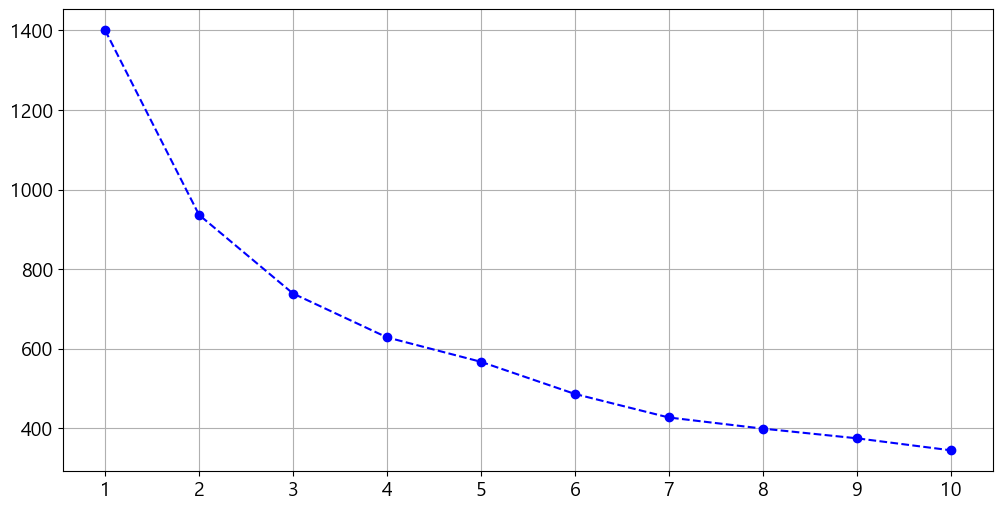

In [8]:
plt.plot(range(1, 11), inertia, marker='o', linestyle='--', color='b')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [10]:
# 위에서 구한 각 군집 개수별 inertia 값을 통해 최적의 군집 수를 찾아낸다.
kn = KneeLocator(range(1, 11), inertia, curve='convex', direction='decreasing')
print(f'수학적으로 계산된 최적의 K : {kn.knee}')

수학적으로 계산된 최적의 K : 3


### 실루엣 계수
- 군집 내 데이터들이 얼마나 밀집해 있는지(응집도)와 군집 간에 얼마나 멀리 떨어져 있는지(분리도)를 동시에 계산하는 지표
- 수학적으로 계산된 최적의 군집 수와 우리가 정한 군집 수에 대한 실루엣 계수가 비슷한지 확인하는 용도로 사용한다.

In [12]:
# 비교할 k 값
k_values = [3, 5]

for k in k_values :
    kmeans = KMeans(n_clusters=k, random_state=42)
    # 학습 및 예측
    labels = kmeans.fit_predict(X_scaled)

    # 전체 데이터의 평균 실루엣 계수 산출
    score = silhouette_score(X_scaled, labels)
    print(f'Cluster K={k}의 실루엣 계수 : {score:.4f}')

Cluster K=3의 실루엣 계수 : 0.3170
Cluster K=5의 실루엣 계수 : 0.2729


- 수학적으로 계산한 최적의 군집 수 3의 실루엣 계수와 데이터 분석을 통해 결정한 군집 수 5의 실루엣 계수가 크게 차이가 나지 않으므로 군집 수 5를 사용해도 된다라고 평가할 수 있다.